Лабораторная работа 6

Выполнила студентка группы 6131-010402D Фролова Анастасия Сергеевна

1:

Считать в pandas.DataFrame любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.


In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from matplotlib import pyplot as plt

import sklearn as sk
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
path = '...'

df = pd.read_csv(Path(path, 'loan_data.csv'))

2:

Датасет и подготовка данных:


Привести описание датасета.


Датасет содержит записи о персональных и финансовых данных. Эти данные используются для понимания факторов финансового риска и моделирования процессов прогнозного моделирования для одобрения кредитов и кредитного скоринга.
* person_age - возраст;
* person_gender - пол;
* person_education - наивысший уровень образования;
* person_income - годовой доход;
* person_emp_exp - количество лет трудового стажа;
* person_home_ownership - статус владения жильем (аренда, собственное, ипотека);
* loan_amnt - запрашиваемая сумма кредита;
* loan_intent — цель кредита;
* loan_int_rate — процентная ставка по кредиту;
* loan_percent_income — сумма кредита в процентах от годового дохода;
* cb_person_cred_hist_length — продолжительность кредитной истории в годах;
* credit_score — кредитный рейтинг человека;
* previous_loan_defaults_on_file — индикатор предыдущих невыплат кредита;
* loan_status — статус одобрения кредита (1 = одобрено; 0 = отклонено).

In [ ]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Осуществить предобработку данных (избавиться от null, убрать некоторые признаки и т.п.) - "подчистить данные".


In [ ]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
cat_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file'] # Столбцы с категориальными признаками

num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status'] # Столбцы с численными

Нормализовать численные данные.


In [ ]:
# Выполним нормализацию

scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

Разбить выборку на обучающую и тестовую.


In [ ]:
# Категориальные признаки, как есть

X_as_is = df.drop('loan_status', axis=1)
y_as_is = df['loan_status']

X_train_as_is, X_test_as_is, y_train_as_is, y_test_as_is = train_test_split(X_as_is,y_as_is, test_size= 0.3, random_state= 42)

In [ ]:
# Кодируем категориальные

df_drop = pd.get_dummies(df, columns=cat_cols, drop_first=False) #OneHot Encoder
df_drop.info() # Проверяем, что кодирование прошло успешно

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 28 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   person_age                          45000 non-null  float64
 1   person_income                       45000 non-null  float64
 2   person_emp_exp                      45000 non-null  float64
 3   loan_amnt                           45000 non-null  float64
 4   loan_int_rate                       45000 non-null  float64
 5   loan_percent_income                 45000 non-null  float64
 6   cb_person_cred_hist_length          45000 non-null  float64
 7   credit_score                        45000 non-null  float64
 8   loan_status                         45000 non-null  float64
 9   person_gender_female                45000 non-null  bool   
 10  person_gender_male                  45000 non-null  bool   
 11  person_education_Associate          45000

In [ ]:
X = df_drop.drop('loan_status', axis=1)
y = df_drop['loan_status']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X,y, test_size= 0.3, random_state= 42)

3:

Для каждого из классификаторов (AdaBoostClassifier, GradientBoostingClassifier, XGBClassifier, CatBoostClassifier)

С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели, использовать выборки с закодированными категориальными признаками.

In [ ]:
!pip install catboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
import catboost
from catboost import CatBoostClassifier

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
# AdaBoost

ADA = AdaBoostClassifier(n_estimators= 50, learning_rate= 1.0, algorithm="SAMME", random_state= 42)
ADA.fit(X_train_cat, y_train_cat)
y_predict = ADA.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict))

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10493
         1.0       0.78      0.80      0.79      3007

    accuracy                           0.90     13500
   macro avg       0.86      0.87      0.86     13500
weighted avg       0.91      0.90      0.91     13500



In [ ]:
# Модель хорошо предсказывает класс 0 и также 1, хоть и несколько хуже, однако все же стоит подобрать гиперпараметры для лучшей модели

In [ ]:
ada_grid = {
    'n_estimators': range(10, 50, 10),  # количество деревьев в ансамбле
    'learning_rate': np.arange(0.01, 1, 0.1),  # скорость обучения
}

ada_grid_search = GridSearchCV(ADA, ada_grid, cv = 5, verbose= 2, n_jobs= -1)
ada_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


GridSearchCV(cv=5,
             estimator=AdaBoostClassifier(algorithm='SAMME', random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01, 0.11, 0.21, 0.31, 0.41, 0.51, 0.61, 0.71, 0.81, 0.91]),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [ ]:
ada_grid_search.best_params_

{'learning_rate': np.float64(0.91), 'n_estimators': 40}

In [ ]:
y_predict_ada = ada_grid_search.predict(X_test_cat)

print("Before grid search:")
print(classification_report(y_test_cat, y_predict))

print("After grid search:")
print(classification_report(y_test_cat, y_predict_ada))

Before grid search:
              precision    recall  f1-score   support

         0.0       0.94      0.93      0.94     10493
         1.0       0.78      0.80      0.79      3007

    accuracy                           0.90     13500
   macro avg       0.86      0.87      0.86     13500
weighted avg       0.91      0.90      0.91     13500

After grid search:
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     10493
         1.0       0.79      0.78      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# После подбора гиперпараметров результат почти не изменился, лишь общая точность выросла на 0.01
# Далее будем осуществлять подбор гиперпараметров для остальных моделей

In [ ]:
# GradientBoostingClassifier

grad_grid = {
    'n_estimators': range(10, 50, 10),
    'learning_rate': np.arange(0.01, 0.1, 0.1),
    'max_depth': range(1, 6),
}

grad_model = GradientBoostingClassifier()

grad_grid_search = GridSearchCV(grad_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

grad_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(), n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [ ]:
grad_grid_search.best_params_

{'learning_rate': np.float64(0.01), 'max_depth': 1, 'n_estimators': 10}

In [ ]:
y_predict_grad = grad_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Данный классификатор неплохо предсказывает класс 0, однако класс 1 определяется плохо

In [ ]:
# XGBoost

# Для начала подберем основные параметры модели

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, grad_grid, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': array([0.01]),
                         'max_depth': range(1, 6),
                         'n_estimators': range(10, 50, 10)},
             verbose=2)

In [ ]:
xgb_grid_search.best_params_

{'learning_rate': np.float64(0.01), 'max_depth': 1, 'n_estimators': 10}

In [ ]:
y_predict_xgb_bef = xgb_grid_search.predict(X_test_cat)
print(classification_report(y_test_cat, y_predict_xgb_bef, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Подбираем дополнительные параметры, может улучшить результат

xgb_model_params = {
    'n_estimators': [10],
    'learning_rate': [0.01],
    'max_depth': [1],
    'gamma': np.arange(0, 1.5, 0.5),
    'lambda': np.arange(0, 2.5, 0.5),
    'alpha': np.arange(0, 1.5, 0.5),
}

xgb_model = XGBClassifier()

xgb_grid_search = GridSearchCV(xgb_model, xgb_model_params, cv = 5, verbose= 2, n_jobs= -1)

xgb_grid_search.fit(X_train_cat, y_train_cat)

Fitting 5 folds for each of 45 candidates, totalling 225 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=None, ...),
             n_jobs=-1,
             param_grid={'alpha': array([0. , 0.5, 1. ]),
                         'gamma': array([0. , 0.5, 1. ]),
                         'lambda': array([0. , 0.5, 1. , 1.5, 2. ]),
                         'learning_rate': [0.01], 'max_depth': [1],
                         'n_estimators': [10]},
             verbose=2)

In [ ]:
xgb_grid_search.best_params_

{'alpha': np.float64(0.0),
 'gamma': np.float64(0.0),
 'lambda': np.float64(0.0),
 'learning_rate': 0.01,
 'max_depth': 1,
 'n_estimators': 10}

In [ ]:
y_predict_xgb_af = xgb_grid_search.predict(X_test_cat)

print("Before params search:")
print(classification_report(y_test_cat, y_predict_xgb_bef, zero_division = 0))

print("After params search:")
print(classification_report(y_test_cat, y_predict_xgb_af, zero_division = 0))

Before params search:
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500

After params search:
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
# Подбор дополнительных параметров не улучшил результат
# Данный классификатор также неплохо предсказывает класс 0, но с классом 1 все также проблемы

In [ ]:
import copy
from copy import deepcopy
from catboost import Pool

In [ ]:
# CatBoost

cat_model = CatBoostClassifier()

cat_grids = {
    'iterations': range(10, 50, 10),
    'learning_rate': np.arange(0.01, 0.1, 0.1),
    'max_depth': range(1, 6),
    'task_type': ['CPU'],
    'early_stopping_rounds': [10]
}

In [ ]:
train_data_cat_grid = Pool(data=X_train_cat, label=y_train_cat)
test_data_cat_grid = Pool(data=X_test_cat, label=y_test_cat)

In [ ]:
cat_grid_search_result = cat_model.grid_search(cat_grids, train_data_cat_grid, cv=5, train_size=0.9375, verbose=False, plot=True)

cat_grid_search_result

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6697364	test: 0.6699056	best: 0.6699056 (0)	total: 55ms	remaining: 495ms
1:	learn: 0.6476691	test: 0.6479912	best: 0.6479912 (1)	total: 62.6ms	remaining: 250ms
2:	learn: 0.6269234	test: 0.6273579	best: 0.6273579 (2)	total: 69.1ms	remaining: 161ms
3:	learn: 0.6074505	test: 0.6079576	best: 0.6079576 (3)	total: 75.6ms	remaining: 113ms
4:	learn: 0.5891224	test: 0.5897412	best: 0.5897412 (4)	total: 81.7ms	remaining: 81.7ms
5:	learn: 0.5719452	test: 0.5726583	best: 0.5726583 (5)	total: 91.6ms	remaining: 61.1ms
6:	learn: 0.5558604	test: 0.5566578	best: 0.5566578 (6)	total: 101ms	remaining: 43.2ms
7:	learn: 0.5525020	test: 0.5533956	best: 0.5533956 (7)	total: 106ms	remaining: 26.5ms
8:	learn: 0.5493214	test: 0.5502784	best: 0.5502784 (8)	total: 111ms	remaining: 12.3ms
9:	learn: 0.5461021	test: 0.5471592	best: 0.5471592 (9)	total: 116ms	remaining: 0us

bestTest = 0.5471592345
bestIteration = 9

0:	learn: 0.6697364	test: 0.6699056	best: 0.6699056 (0)	total: 9.38ms	remaining: 178ms
1:

{'params': {'task_type': 'CPU',
  'depth': 5,
  'od_wait': 10,
  'learning_rate': 0.01,
  'iterations': 40},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23,
               24,
               25,
               26,
               27,
               28,
               29,
               30,
               31,
               32,
               33,
               34,
               35,
               36,
               37,
               38,
               39],
              'test-Logloss-mean': [0.6694122127858426,
               0.6483727505779866,
  

In [ ]:
cat_model_after = CatBoostClassifier(iterations = 40, max_depth=5, learning_rate=0.01)
cat_model_after.fit(train_data_cat_grid)

0:	learn: 0.6688365	total: 9.45ms	remaining: 368ms
1:	learn: 0.6473838	total: 18.2ms	remaining: 346ms
2:	learn: 0.6254374	total: 26.7ms	remaining: 329ms
3:	learn: 0.6056049	total: 35.1ms	remaining: 316ms
4:	learn: 0.5853510	total: 43.4ms	remaining: 304ms
5:	learn: 0.5673854	total: 51.6ms	remaining: 292ms
6:	learn: 0.5492645	total: 60ms	remaining: 283ms
7:	learn: 0.5321010	total: 68.2ms	remaining: 273ms
8:	learn: 0.5171997	total: 76.5ms	remaining: 263ms
9:	learn: 0.5018526	total: 84.7ms	remaining: 254ms
10:	learn: 0.4872332	total: 94.7ms	remaining: 250ms
11:	learn: 0.4745054	total: 105ms	remaining: 245ms
12:	learn: 0.4618285	total: 114ms	remaining: 236ms
13:	learn: 0.4488637	total: 123ms	remaining: 228ms
14:	learn: 0.4373845	total: 131ms	remaining: 218ms
15:	learn: 0.4263671	total: 139ms	remaining: 209ms
16:	learn: 0.4153852	total: 151ms	remaining: 204ms
17:	learn: 0.4063648	total: 160ms	remaining: 195ms
18:	learn: 0.3971131	total: 169ms	remaining: 187ms
19:	learn: 0.3884280	total: 179m

In [ ]:
y_predict_cat = cat_model_after.predict(test_data_cat_grid)
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.85      0.73      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.89      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Результат для класса 0 хороший, однако для класса 1 он несколько хуже

Обучить модели XGBClassifier и CatBoostClassifier
 с найденными гиперпараметрами на обучающей выборке с категориальными признаками "как есть".

In [ ]:
cat_cols_1 = [var for var in X_train_as_is.columns if X_train_as_is[var].dtype == 'object']

X_cat_train_1 = deepcopy(X_train_as_is)
X_cat_test_1 = deepcopy(X_test_as_is)

for col in cat_cols:
    X_cat_train_1[col] = pd.Categorical(X_cat_train_1[col])
    X_cat_test_1[col] = pd.Categorical(X_cat_test_1[col])

train_data_cat = Pool(data=X_cat_train_1, label=y_train_cat, cat_features=cat_cols_1)
test_data_cat  = Pool(data=X_cat_test_1, label=y_test_cat, cat_features=cat_cols_1)

In [ ]:
xgb_model_best = XGBClassifier(n_estimators=10, max_depth=1, learning_rate=0.01, alpha=0.0, gamma=0.0, reg_lambda = 0, objective='binary:logistic', enable_categorical=True, max_cat_to_onehot=10000)
xgb_model_best.fit(X_cat_train_1, y_train_cat)
y_ce_pred_xgb = xgb_model_best.predict(X_cat_test_1)
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))

              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500



In [ ]:
cat_model_best = CatBoostClassifier(n_estimators=40, max_depth=5, learning_rate=0.01)
cat_model_best.fit(train_data_cat)
y_ce_pred_cat = cat_model_best.predict(X_cat_test_1)
print("Results:")
print(classification_report(y_test_cat, y_ce_pred_cat))

0:	learn: 0.6861750	total: 17.3ms	remaining: 673ms
1:	learn: 0.6796066	total: 30.3ms	remaining: 575ms
2:	learn: 0.6729929	total: 40.4ms	remaining: 498ms
3:	learn: 0.6665349	total: 50.6ms	remaining: 455ms
4:	learn: 0.6601537	total: 61ms	remaining: 427ms
5:	learn: 0.6540066	total: 71.4ms	remaining: 405ms
6:	learn: 0.6480538	total: 82.4ms	remaining: 389ms
7:	learn: 0.6421419	total: 94.2ms	remaining: 377ms
8:	learn: 0.6363208	total: 104ms	remaining: 360ms
9:	learn: 0.6305454	total: 115ms	remaining: 344ms
10:	learn: 0.6249829	total: 125ms	remaining: 329ms
11:	learn: 0.6194979	total: 135ms	remaining: 314ms
12:	learn: 0.6139953	total: 145ms	remaining: 301ms
13:	learn: 0.6086754	total: 155ms	remaining: 288ms
14:	learn: 0.6033926	total: 167ms	remaining: 279ms
15:	learn: 0.5981977	total: 179ms	remaining: 269ms
16:	learn: 0.5931688	total: 190ms	remaining: 257ms
17:	learn: 0.5881837	total: 200ms	remaining: 245ms
18:	learn: 0.5834001	total: 211ms	remaining: 233ms
19:	learn: 0.5788087	total: 229ms	r

Итого получить 6 обученных моделей.


Вывести метрики на тестовом наборе (как минимум classification_report, другие по желанию).


In [ ]:
print("AdaBoostClassifier")
print(classification_report(y_test_cat, y_predict_ada))
print("GradientBoostingClassifier")
print(classification_report(y_test_cat, y_predict_grad, zero_division = 0))
print("XGBClassifier with coded")
print(classification_report(y_test_cat, y_predict_xgb_af, zero_division = 0))
print("CatBoostClassifier with coded")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("XGBClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_xgb, zero_division = 0))
print("CatBoostClassifier with default")
print(classification_report(y_test_cat, y_ce_pred_cat))

AdaBoostClassifier
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     10493
         1.0       0.79      0.78      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.87      0.86      0.86     13500
weighted avg       0.91      0.91      0.91     13500

GradientBoostingClassifier
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
weighted avg       0.60      0.78      0.68     13500

XGBClassifier with coded
              precision    recall  f1-score   support

         0.0       0.78      1.00      0.87     10493
         1.0       0.00      0.00      0.00      3007

    accuracy                           0.78     13500
   macro avg       0.39      0.50      0.44     13500
wei

Сравнить модели, выбрать лучшую.


In [ ]:
# Вывод: Лучший результат показали модели ADABoost и CatBoost с accuracy в 0.91, однако лучшим по метрике precision оказался CatBoost
# Выберем в качестве лучшей модели CatBoostClassifier with coded

4:

Важность признаков:


In [ ]:
import shap

С использованием shap.TreeExplainer получить SHAP
-значения для лучшей модели.

In [ ]:
tree_explainer = shap.TreeExplainer(cat_model_after)
shap_values = tree_explainer.shap_values(train_data_cat_grid)

Построить график shap.plots.force для одного объекта выборки и для среза произвольного размера.


In [ ]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0,:], X_train_cat.iloc[0,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

In [ ]:
shap.initjs()
shap_fp = shap.plots.force(tree_explainer.expected_value, shap_values[0:100,:], X_train_cat.iloc[0:100,:])

from IPython.display import HTML
HTML(f"<div style='background-color: Lavender;'>{shap.getjs() + shap_fp.html()}</div>")

Построить график shap.plots.bar для одного объекта выборки.


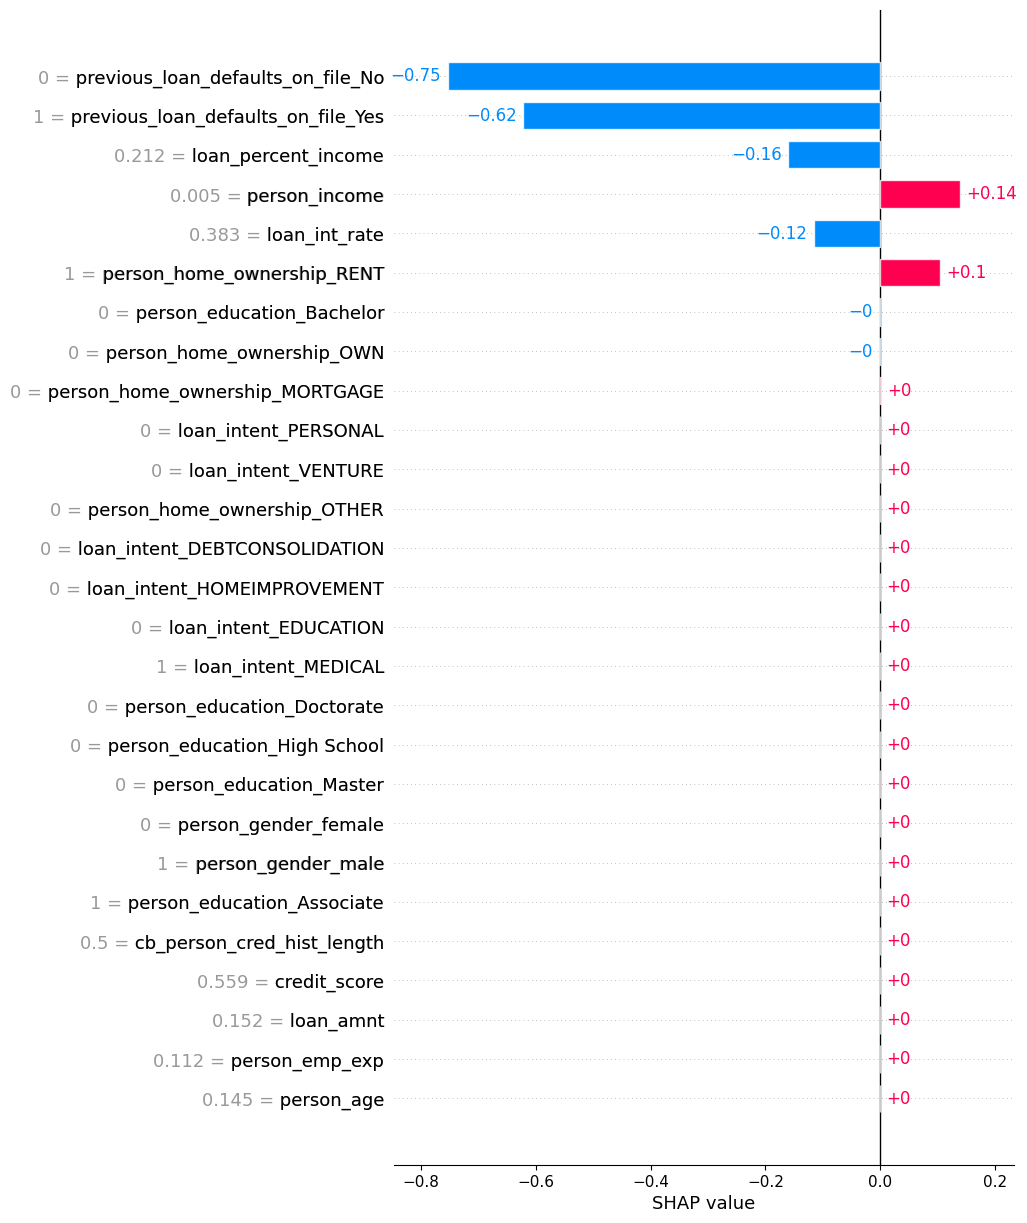

In [ ]:
te_df_shap_values  = tree_explainer(X_train_cat)
shap_bp = shap.plots.bar(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить график shap.plots.waterfall для одного объекта выборки.


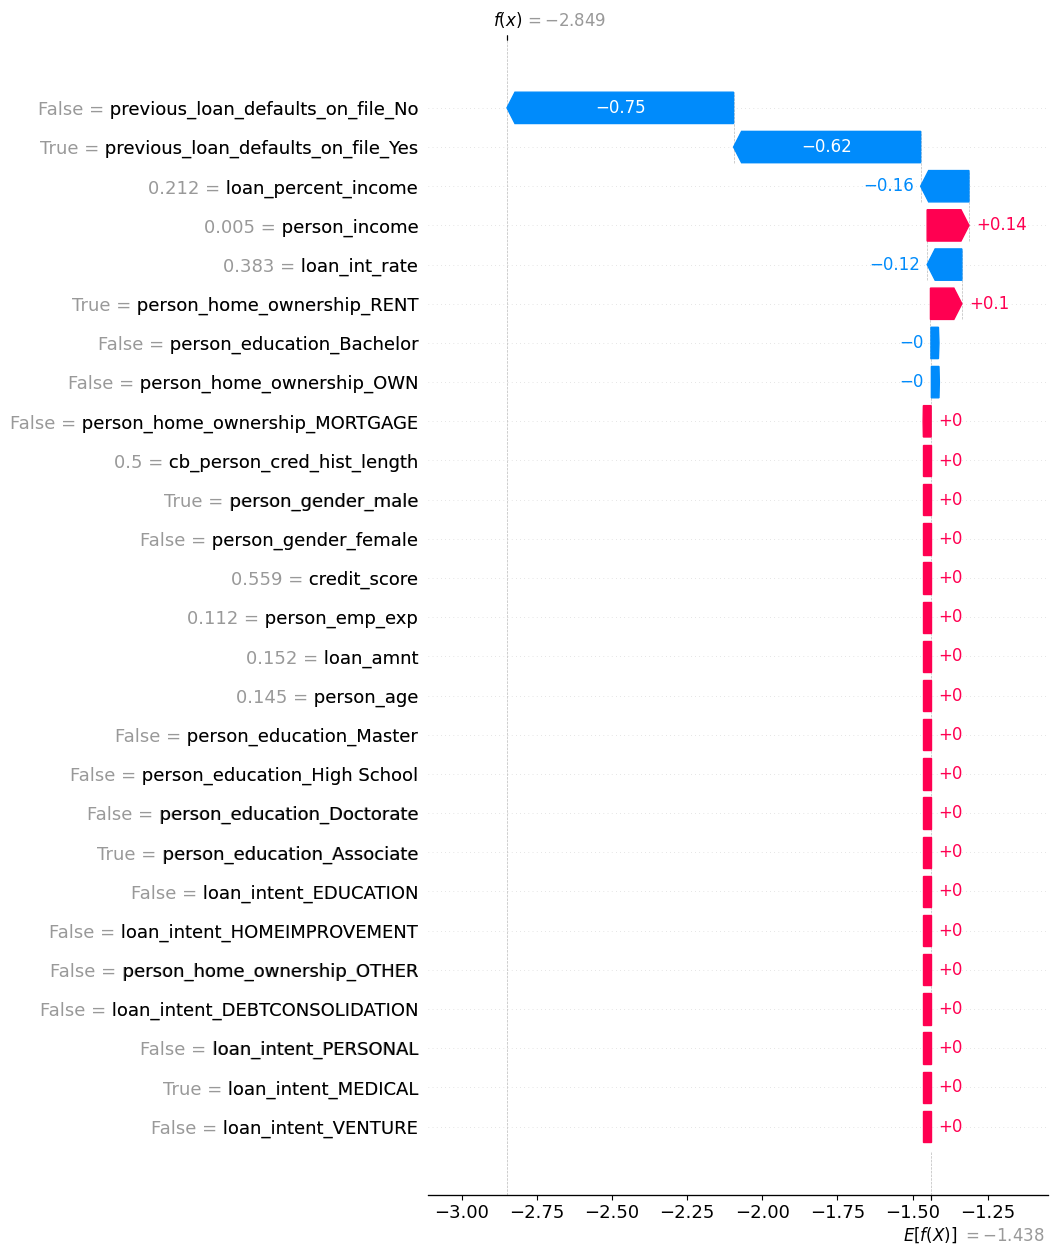

In [ ]:
shap.plots.waterfall(te_df_shap_values[0], max_display=X_train_cat.shape[1])

Построить 2 графика shap.plots.scatter для какого-нибудь признака. На одном раскрасить относительно себя, на втором – относительно другого признака.


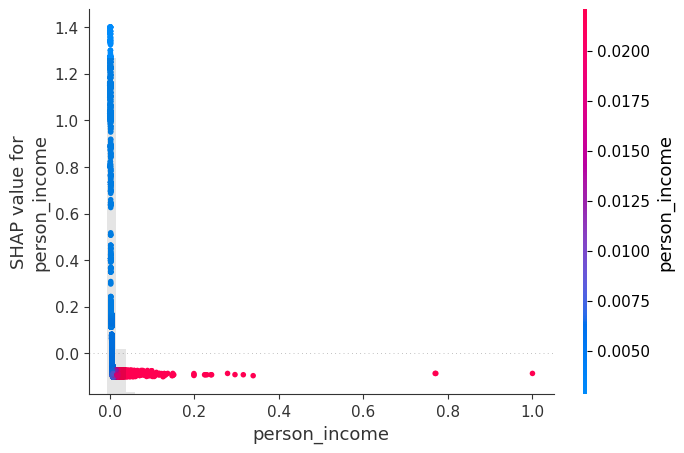

In [ ]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_income"])

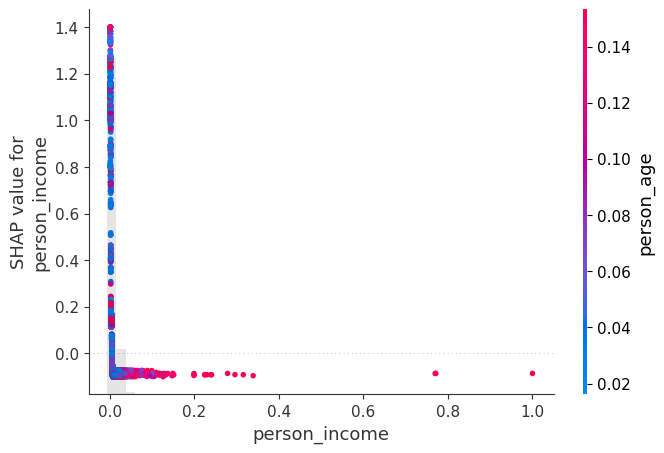

In [ ]:
shap.plots.scatter(te_df_shap_values[:, "person_income"], color=te_df_shap_values[:, "person_age"])

Построить график shap.plots.beeswarm для всех признаков.


<Axes: xlabel='SHAP value (impact on model output)'>

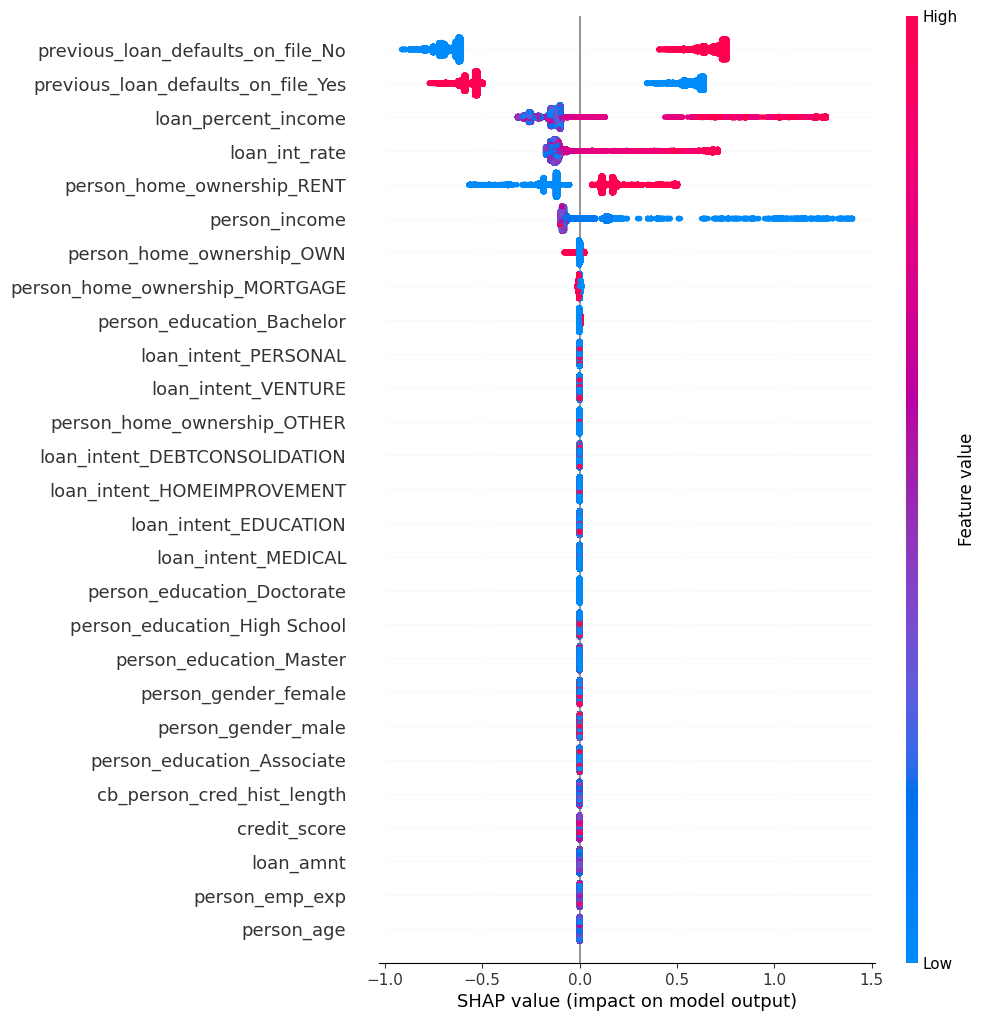

In [ ]:
shap.plots.beeswarm(te_df_shap_values, max_display=X_train_cat.shape[1], show=False)

Построить график shap.plots.bar для всех признаков.


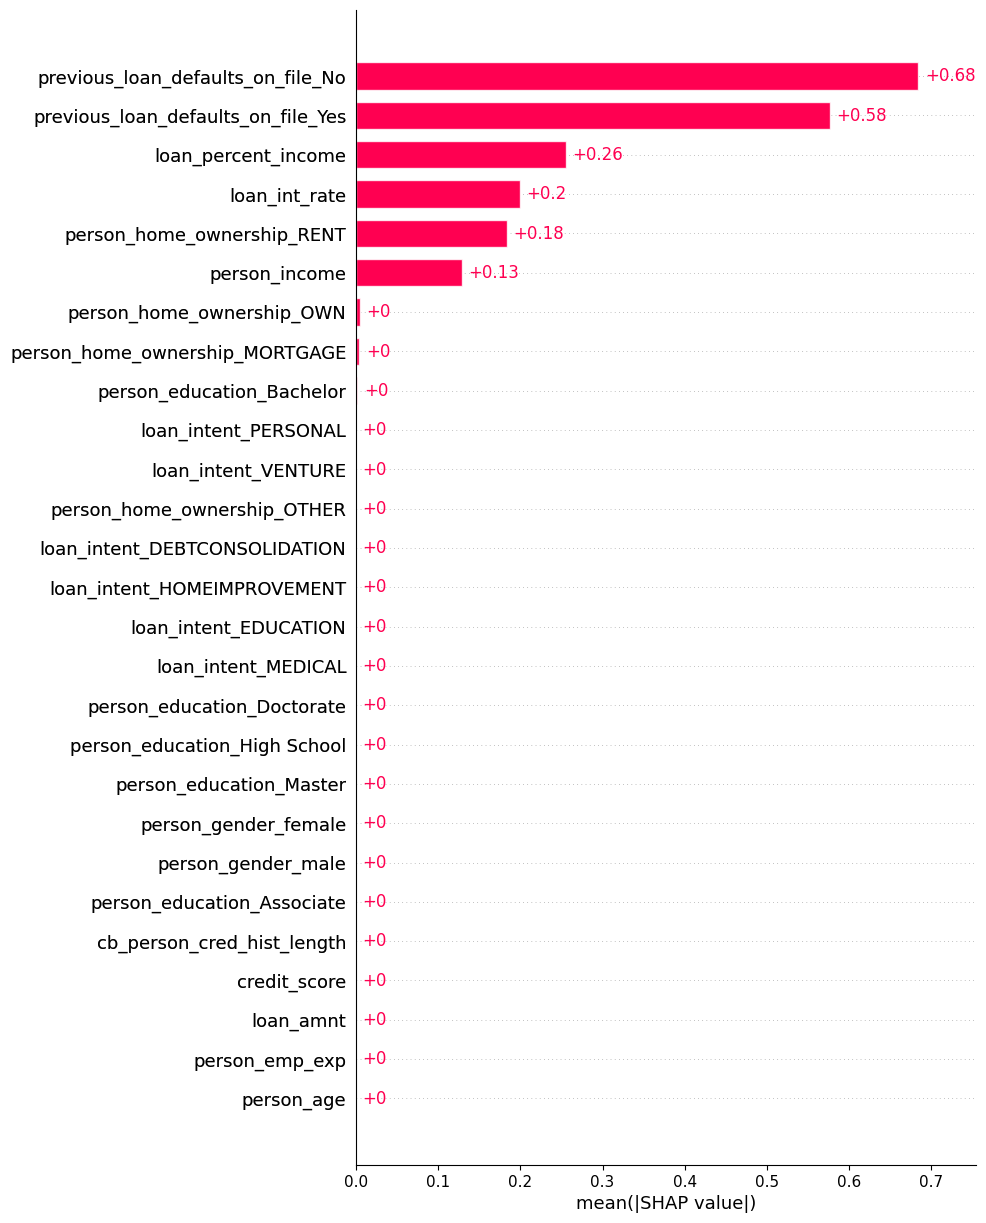

In [ ]:
shap.plots.bar(te_df_shap_values, max_display=X_train_cat.shape[1])

На основании двух последних графиков и/или используя feature_importance отфильровать признаки (отразить сформулированные выводы в тексте), переобучить лучшую модель.


In [ ]:
# Оставим признаки с важностью больше 0

In [ ]:
filter_cols = ['previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes','loan_percent_income', 'loan_int_rate', "person_home_ownership_RENT", "person_income"]

In [ ]:
cat_model_after.fit(X_train_cat[filter_cols], y_train_cat)

0:	learn: 0.6862335	total: 4.93ms	remaining: 192ms
1:	learn: 0.6795069	total: 9.58ms	remaining: 182ms
2:	learn: 0.6728344	total: 13.2ms	remaining: 163ms
3:	learn: 0.6663626	total: 16.8ms	remaining: 151ms
4:	learn: 0.6597458	total: 20.3ms	remaining: 142ms
5:	learn: 0.6535340	total: 23.9ms	remaining: 135ms
6:	learn: 0.6475009	total: 27.4ms	remaining: 129ms
7:	learn: 0.6412606	total: 31ms	remaining: 124ms
8:	learn: 0.6352870	total: 34.7ms	remaining: 120ms
9:	learn: 0.6293169	total: 38.4ms	remaining: 115ms
10:	learn: 0.6234336	total: 41.9ms	remaining: 110ms
11:	learn: 0.6177562	total: 45.4ms	remaining: 106ms
12:	learn: 0.6121898	total: 48.8ms	remaining: 101ms
13:	learn: 0.6067035	total: 52.4ms	remaining: 97.4ms
14:	learn: 0.6013377	total: 55.8ms	remaining: 93.1ms
15:	learn: 0.5959488	total: 59.3ms	remaining: 88.9ms
16:	learn: 0.5907386	total: 62.7ms	remaining: 84.8ms
17:	learn: 0.5854830	total: 67.9ms	remaining: 83ms
18:	learn: 0.5805392	total: 71.3ms	remaining: 78.8ms
19:	learn: 0.5754059

Сравнить метрики до и после фильтрации.


In [ ]:
y_predict_filter = cat_model_after.predict(X_test_cat[filter_cols])
print("Before:")
print(classification_report(y_test_cat, y_predict_cat, zero_division = 0))
print("After:")
print(classification_report(y_test_cat, y_predict_filter, zero_division = 0))

Before:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.85      0.73      0.79      3007

    accuracy                           0.91     13500
   macro avg       0.89      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500

After:
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94     10493
         1.0       0.84      0.74      0.78      3007

    accuracy                           0.91     13500
   macro avg       0.88      0.85      0.86     13500
weighted avg       0.91      0.91      0.91     13500



In [ ]:
# Метрики почти не изменились, разница в сотых в некоторых параметрах, однако количество признаков было уменьшено до 6

Визуализировать полученное дерево решений.


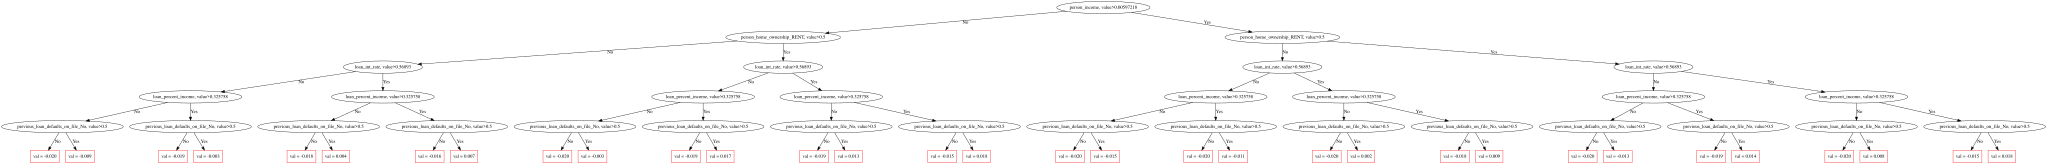

In [ ]:
cat_model_after.plot_tree(
    tree_idx=0,
    pool=Pool(data=X_train_cat[filter_cols], label=y_train_cat)
)


5:

Регрессия:


С использованием GridSearchCV/grid_search осуществить подбор гиперпараметра модели линейной регрессии с использованием XGBoost или CatBoost

In [ ]:
from catboost import CatBoostRegressor

In [ ]:
X_train_cat

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,person_gender_female,person_gender_male,...,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_No,previous_loan_defaults_on_file_Yes
30159,0.145161,0.004668,0.112,0.152174,0.383402,0.212121,0.500000,0.558696,False,True,...,False,True,False,False,False,True,False,False,False,True
6777,0.032258,0.002788,0.024,0.188406,0.356653,0.378788,0.035714,0.563043,True,False,...,False,True,True,False,False,False,False,False,True,False
36563,0.064516,0.007747,0.032,0.188406,0.743484,0.166667,0.107143,0.513043,True,False,...,False,False,False,True,False,False,False,False,False,True
11784,0.048387,0.011660,0.024,0.020290,0.331276,0.015152,0.000000,0.591304,False,True,...,False,False,False,False,False,False,True,False,True,False
10370,0.016129,0.002996,0.000,0.275362,0.383402,0.515152,0.035714,0.528261,False,True,...,False,True,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.048387,0.011185,0.048,0.293478,0.041838,0.181818,0.071429,0.367391,False,True,...,False,False,False,True,False,False,False,False,False,True
44732,0.040323,0.003722,0.024,0.155826,0.430041,0.257576,0.071429,0.558696,True,False,...,False,False,False,False,True,False,False,False,True,False
38158,0.104839,0.006996,0.072,0.295855,0.364883,0.272727,0.250000,0.569565,True,False,...,False,False,False,False,False,False,False,True,False,True
860,0.048387,0.023719,0.048,0.565217,0.862140,0.166667,0.035714,0.465217,False,True,...,False,True,True,False,False,False,False,False,True,False


In [ ]:
target_train = X_train_cat['loan_percent_income']
X_train_regr = pd.concat([X_train_cat.drop(['loan_percent_income'], axis=1), y_train_cat], axis=1)
col = ['loan_status']
for col in X_train_regr:
    X_train_regr[col] = X_train_regr[col].astype('int64')
X_train_regr['loan_status'] = pd.Categorical(X_train_regr['loan_status'])

target_test = X_test_cat['loan_percent_income']
X_test_regr = pd.concat([X_test_cat.drop(['loan_percent_income'], axis=1), y_test_cat], axis=1)
for col in X_test_regr:
    X_test_regr[col] = X_test_regr[col].astype('int64')
X_test_regr['loan_status'] = pd.Categorical(X_test_regr['loan_status'])

In [ ]:
cat_cols_2 = [var for var in X_train_regr.columns if X_train_regr[var].dtype == 'category']

train_data_cat_regr = Pool(data=X_train_regr, label=target_train, cat_features=cat_cols_2)
test_data_cat_regr = Pool(data=X_test_regr, label=target_test, cat_features=cat_cols_2)

In [ ]:
model = CatBoostRegressor(random_state=42)

CatBoost_param = {
    'iterations': [50, 100],
    'learning_rate': np.arange(0.05, 1.05, 0.05),
    'depth': np.arange(1, 5, 1),
    'task_type': ['CPU'],
    'early_stopping_rounds': [10]
}

cat_grid_search_result_2 = model.grid_search(CatBoost_param, train_data_cat_regr, cv=5, train_size=0.9375, verbose=False, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Выходные данные были обрезаны до нескольких последних строк (5000).
7:	learn: 0.1184686	test: 0.1237933	best: 0.1237379 (6)	total: 22.6ms	remaining: 119ms
8:	learn: 0.1184660	test: 0.1238104	best: 0.1237379 (6)	total: 25.3ms	remaining: 115ms
9:	learn: 0.1184642	test: 0.1238080	best: 0.1237379 (6)	total: 27.9ms	remaining: 111ms
10:	learn: 0.1184555	test: 0.1238218	best: 0.1237379 (6)	total: 30.4ms	remaining: 108ms
11:	learn: 0.1184522	test: 0.1238086	best: 0.1237379 (6)	total: 33ms	remaining: 105ms
12:	learn: 0.1184290	test: 0.1237227	best: 0.1237227 (12)	total: 36.1ms	remaining: 103ms
13:	learn: 0.1184276	test: 0.1237209	best: 0.1237209 (13)	total: 38.7ms	remaining: 99.5ms
14:	learn: 0.1184162	test: 0.1237129	best: 0.1237129 (14)	total: 41.3ms	remaining: 96.5ms
15:	learn: 0.1184125	test: 0.1237721	best: 0.1237129 (14)	total: 43.8ms	remaining: 93.2ms
16:	learn: 0.1184117	test: 0.1237713	best: 0.1237129 (14)	total: 46.3ms	remaining: 89.9ms
17:	learn: 0.1184061	test: 0.1238232	best: 0.123

In [ ]:
cat_grid_search_result_2

{'params': {'task_type': 'CPU',
  'depth': 3,
  'od_wait': 10,
  'learning_rate': 1,
  'iterations': 50},
 'cv_results': defaultdict(list,
             {'iterations': [0,
               1,
               2,
               3,
               4,
               5,
               6,
               7,
               8,
               9,
               10,
               11,
               12,
               13,
               14,
               15,
               16,
               17,
               18,
               19,
               20,
               21,
               22,
               23],
              'test-RMSE-mean': [0.11944521945840987,
               0.11907963569007532,
               0.11898761107525849,
               0.1189411083622127,
               0.11890616417383267,
               0.11886174638045652,
               0.11884731671957953,
               0.1188369334717877,
               0.11887023741448824,
               0.11887586464161806,
               0.1188690

In [ ]:
best_reg = CatBoostRegressor(task_type='CPU', depth=3, learning_rate=1, iterations=50, random_state=42)

In [ ]:
best_reg.fit(X_train_regr, target_train, cat_features=cat_cols_2)

0:	learn: 0.1198369	total: 22ms	remaining: 1.08s
1:	learn: 0.1189978	total: 34ms	remaining: 815ms
2:	learn: 0.1187852	total: 45.2ms	remaining: 708ms
3:	learn: 0.1187162	total: 52.8ms	remaining: 608ms
4:	learn: 0.1186903	total: 58.7ms	remaining: 528ms
5:	learn: 0.1186659	total: 61.7ms	remaining: 452ms
6:	learn: 0.1186555	total: 64.6ms	remaining: 397ms
7:	learn: 0.1186376	total: 67.8ms	remaining: 356ms
8:	learn: 0.1186110	total: 70.6ms	remaining: 321ms
9:	learn: 0.1185995	total: 73.6ms	remaining: 294ms
10:	learn: 0.1185985	total: 76.3ms	remaining: 271ms
11:	learn: 0.1185897	total: 79.3ms	remaining: 251ms
12:	learn: 0.1185714	total: 82.2ms	remaining: 234ms
13:	learn: 0.1185647	total: 85.1ms	remaining: 219ms
14:	learn: 0.1185597	total: 87.8ms	remaining: 205ms
15:	learn: 0.1185445	total: 90.7ms	remaining: 193ms
16:	learn: 0.1185300	total: 93.6ms	remaining: 182ms
17:	learn: 0.1185217	total: 96.4ms	remaining: 171ms
18:	learn: 0.1185068	total: 99.3ms	remaining: 162ms
19:	learn: 0.1185043	total

In [ ]:
y_pred_reg = best_reg.predict(X_test_regr)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Вывести метрики MSE, MAE и R2
 на тестовом наборе.

In [ ]:
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

Средняя квадратичная ошибка (MSE): 0.13
Средняя абсолютная ошибка (MAE): 0.30
Коэффициент детерминации (R2): 0.23


Переобучить модель на отфильтрованном наборе признаков из пункта 4.


In [ ]:
print(filter_cols)

['previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes', 'loan_percent_income', 'loan_int_rate', 'person_home_ownership_RENT', 'person_income']


In [ ]:
# В отфильтрованном наборе есть признак, по которому осуществляется регрессия, исключим его и добавим другие признаки

new_filter_cols = ['previous_loan_defaults_on_file_No', 'previous_loan_defaults_on_file_Yes', 'person_home_ownership_OWN', 'person_home_ownership_MORTGAGE','loan_int_rate', 'person_home_ownership_RENT', 'person_income']

In [ ]:
best_reg.fit(X_train_regr[new_filter_cols], target_train, cat_features=new_filter_cols)

0:	learn: 0.1262028	total: 14.1ms	remaining: 692ms
1:	learn: 0.1262008	total: 28.6ms	remaining: 686ms
2:	learn: 0.1261996	total: 39.8ms	remaining: 623ms
3:	learn: 0.1261990	total: 43.5ms	remaining: 501ms
4:	learn: 0.1261976	total: 54.8ms	remaining: 493ms
5:	learn: 0.1261975	total: 58.7ms	remaining: 431ms
6:	learn: 0.1261972	total: 62.7ms	remaining: 385ms
7:	learn: 0.1261970	total: 74.3ms	remaining: 390ms
8:	learn: 0.1261943	total: 81.9ms	remaining: 373ms
9:	learn: 0.1261933	total: 92.6ms	remaining: 370ms
10:	learn: 0.1261931	total: 96.3ms	remaining: 342ms
11:	learn: 0.1261925	total: 104ms	remaining: 330ms
12:	learn: 0.1261914	total: 121ms	remaining: 344ms
13:	learn: 0.1261913	total: 125ms	remaining: 322ms
14:	learn: 0.1261913	total: 135ms	remaining: 315ms
15:	learn: 0.1261912	total: 139ms	remaining: 295ms
16:	learn: 0.1261911	total: 149ms	remaining: 289ms
17:	learn: 0.1261911	total: 157ms	remaining: 279ms
18:	learn: 0.1261911	total: 164ms	remaining: 268ms
19:	learn: 0.1261911	total: 18

In [ ]:
y_pred_reg_fil = best_reg.predict(X_test_regr[new_filter_cols])

Сравнить метрики до и после фильтрации.


In [ ]:
print("Before:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg):.2f}")

print("After:")
print(f"Средняя квадратичная ошибка (MSE): {mean_squared_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Средняя абсолютная ошибка (MAE): {mean_absolute_error(y_test_cat, y_pred_reg_fil):.2f}")
print(f"Коэффициент детерминации (R2): {r2_score(y_test_cat, y_pred_reg_fil):.2f}")

Before:
Средняя квадратичная ошибка (MSE): 0.13
Средняя абсолютная ошибка (MAE): 0.30
Коэффициент детерминации (R2): 0.23
After:
Средняя квадратичная ошибка (MSE): 0.16
Средняя абсолютная ошибка (MAE): 0.32
Коэффициент детерминации (R2): 0.09


In [ ]:
# Метрики стали хуже, так как рассматриваемый признак loan_percent_income является довольно важным для прогнозов в случае данного датасета
# Хоть количество признаков стало меньше, а важный признак был исключен из рассмотрения, ошибки стали лишь немного больше, в отличие от изменений в R2